# 02: GRPO on GSM8K
Sweep hyperparameters for GRPO training on Qwen2.5-0.5B-GSM8K-SFT.
Uses binary reward (1.0/0.0) with parameterized config.

In [1]:
!pip install -qUU git+https://github.com/tripathysagar/rlhf-gsm8k.git

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 528.8/528.8 kB 15.9 MB/s eta 0:00:00


In [2]:
import wandb
from google.colab import userdata

wandb.login(key=userdata.get('wandb'))

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: [wandb.login()] Using explicit session credentials for https://api.wandb.ai.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: tripathysagar08 to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

In [3]:
from gsm8k_utils.grpo import GRPOExperiment
import numpy as np

## Base Config

In [ ]:
cfg = dict(
    max_steps=100,
    max_completion_length=512,
)

## Hyperparameter Sweep

In [ ]:
all_sweeps = [
    {"num_generations": 8},
    {"num_generations": 16},
    {"beta": 0.01},
    {"beta": 0.02},
    {"beta": 0.04},
    {"learning_rate": 1e-5},
    {"learning_rate": 5e-5},
    {"learning_rate": 1e-4},
    {"sft_frac": 0.0},
    {"sft_frac": 0.5},
    {"sft_frac": 1.0},
]

sweep_results = []
for s in all_sweeps:
    run_name = "sweep-" + "-".join(f"{k}={v}" for k, v in s.items())
    run_cfg = {**cfg, **s, "wandb_run_name": run_name}
    acc = GRPOExperiment(run_cfg)()
    sweep_results.append({**s, "accuracy": acc})
    print(f"{s} → accuracy: {acc:.4f}")

sweep_results

README.md: 0.00B [00:00, ?B/s]

main/train-00000-of-00001.parquet:   0%|          | 0.00/2.31M [00:00<?, ?B/s]

main/test-00000-of-00001.parquet:   0%|          | 0.00/419k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/7473 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1319 [00:00<?, ? examples/s]

...

Evaluating: 100%|██████████| 6/6 [00:41<00:00,  6.95s/it]


Final Accuracy: 223/660 = 33.79%


eval/accuracy,▁
profiling/Time taken: GRPOTrainer._calculate_rewards,▂▂▁▃▂▆▇▂▅▂▃▅▄▃▅▂▁█▄▂▃▁▃▂▁▃▂▃▆▄▆▂▇▂▃▁▅▂▄▂
profiling/Time taken: GRPOTrainer._get_per_token_logps_and_entropies,▁▁▁▁█▁▁█▁█▁▁▁▁▁▁▁▁▁▁▁█▁▁▁█▁▁█▁▁█▁▁▁▁█▁▁█
profiling/Time taken: GRPOTrainer._prepare_inputs,▁▁▁▁█▁▁▁▁▁▁▁▁█▁▁▁▁██▁▁▁█▁▁█▁▁▁▁▁▁▁▁▁▁█▁▁
profiling/Time taken: GRPOTrainer.compute_loss,▄▅▇▇▅▇▅█▄██▄▃▄▄▄▄▄▄▁▂▅▂▂▃▃▅▂▂▃▅▂▄▃▄▄▄▂▁▃
profiling/Time taken: GRPOTrainer.reward_fn,▁▆▇▂█▇▁▁▂▁▅▆▆▄▃▄▂▁▄▄▄▁▃▅▄▇▁▂▄▃▄█▆▁▇▁▂▂▁▂
profiling/Time taken: GRPOTrainer.transformers.generate,▇▆█▃▃▃▇▂▃▄▅▅▃▂▂▅▇▁▅▃▆▆▅▅▃▁▁▁▅▆▄▃▄▄▄▂▂▃▃▄
train/clip_ratio/high_max,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
train/clip_ratio/high_mean,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
train/clip_ratio/low_mean,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
+23,...


{'sft_frac': 1.0} → accuracy: 0.3379


[{'num_generations': 8, 'accuracy': 0.32575757575757575},
 {'num_generations': 16, 'accuracy': 0.31666666666666665},
 {'beta': 0.01, 'accuracy': 0.3696969696969697},
 {'beta': 0.02, 'accuracy': 0.353030303030303},
 {'beta': 0.04, 'accuracy': 0.37424242424242427},
 {'learning_rate': 1e-05, 'accuracy': 0.3393939393939394},
 {'learning_rate': 5e-05, 'accuracy': 0.3560606060606061},
 {'learning_rate': 0.0001, 'accuracy': 0.2681818181818182},
 {'sft_frac': 0.0, 'accuracy': 0.2772727272727273},
 {'sft_frac': 0.5, 'accuracy': 0.33181818181818185},
 {'sft_frac': 1.0, 'accuracy': 0.3378787878787879}]

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

In [5]:
def plot_seed_runs(project, n=3):
    """Fetch last n runs and plot accuracy per seed."""
    api = wandb.Api()
    runs = list(api.runs(project, order="-created_at"))[:n]
    finished = [r for r in runs if r.state == "finished" and r.summary.get("eval/accuracy")]
    if not finished:
        print("No finished runs yet")
        return pd.DataFrame()

    df = pd.DataFrame([{
        "seed": r.name.split("seed")[-1],
        "accuracy": round(r.summary["eval/accuracy"] * 100, 2)
    } for r in finished])

    colors = ['#2ecc71' if a == df['accuracy'].max() else 'steelblue' for a in df['accuracy']]
    df.plot.bar(x='seed', y='accuracy', color=colors, legend=False, figsize=(6, 4))
    plt.title('Multi-Seed Validation')
    plt.ylabel('Accuracy (%)')
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()

    print(f"Mean: {df['accuracy'].mean():.2f}% ± {df['accuracy'].std():.2f}%")
    return df

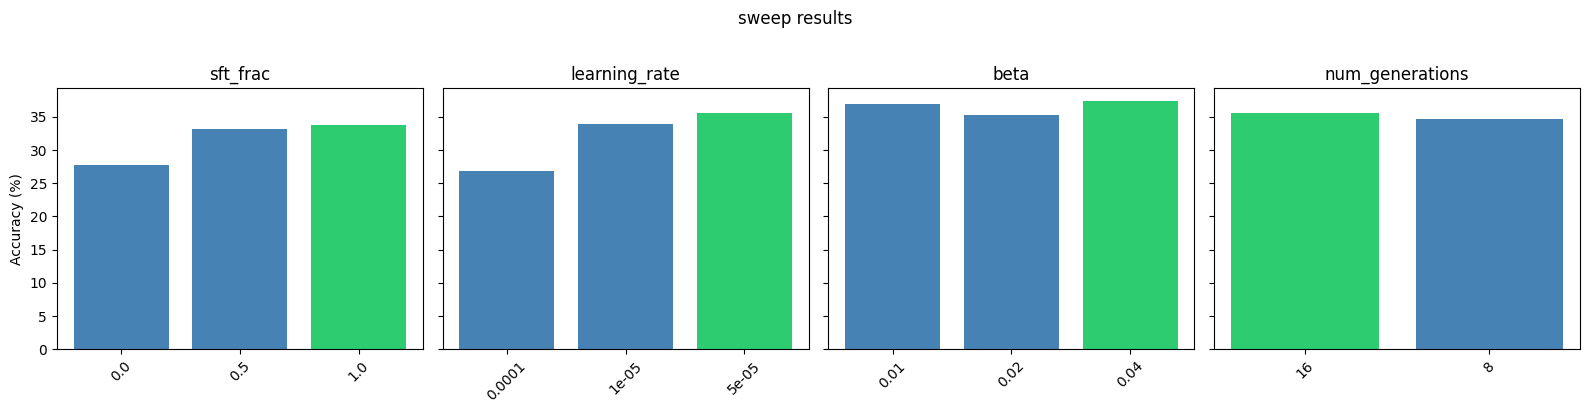

In [ ]:
sweep_df = plot_seed_runs("tripathysagar08/grpo-gsm8k", len(all_sweeps))


In [ ]:
best = sweep_df.loc[sweep_df.groupby('param')['accuracy'].idxmax()]
print(best[['param', 'value', 'accuracy']].to_string(index=False))

          param value  accuracy
           beta  0.04     37.42
  learning_rate 5e-05     35.61
num_generations    16     35.61
       sft_frac   1.0     33.79


In [ ]:
best_cfg = dict(
    max_steps=200,
    max_completion_length=512,
    **{row['param']: float(row['value']) for _, row in best.iterrows()},
)
best_cfg

{'max_steps': 200,
 'max_completion_length': 512,
 'beta': 0.04,
 'learning_rate': 5e-05,
 'num_generations': 16.0,
 'sft_frac': 1.0}

In [ ]:
# Fix int params
best_cfg['num_generations'] = int(best_cfg['num_generations'])
best_cfg

{'max_steps': 200,
 'max_completion_length': 512,
 'beta': 0.04,
 'learning_rate': 5e-05,
 'num_generations': 16,
 'sft_frac': 1.0}

## Best Config → Multi-Seed Validation

In [ ]:
seeds = [42, 1337, 7]
seed_results = {}
for s in seeds:
    run_cfg = {**best_cfg, "seed": s}
    exp = GRPOExperiment(run_cfg)
    seed_results[s] = exp()
    print(f"Seed {s}: {seed_results[s]:.2%}")

accs = list(seed_results.values())
print(f"\nMean: {np.mean(accs):.2%} ± {np.std(accs):.2%}")

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

trainable params: 8,798,208 || all params: 502,830,976 || trainable%: 1.7497


Map:   0%|          | 0/1024 [00:00<?, ? examples/s]

Map:   0%|          | 0/660 [00:00<?, ? examples/s]

Step,Training Loss
1,0.000000
2,0.000000
3,0.000069
4,0.000090
5,0.000073
6,0.000085
7,-0.003126
8,0.000096
9,0.000070
10,-0.009781


...

Step,Training Loss
1,0.000000
2,0.000000
3,-0.001772
4,0.000077
5,0.000076
6,0.000790
7,-0.003770
8,0.000078
9,0.000074
10,0.000071


Evaluating: 100%|██████████| 6/6 [00:41<00:00,  6.95s/it]


Final Accuracy: 230/660 = 34.85%


eval/accuracy,▁
profiling/Time taken: GRPOTrainer._calculate_rewards,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁█▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
profiling/Time taken: GRPOTrainer._get_per_token_logps_and_entropies,▁▁██▁█▁▁▁▁▁▁▁▁▁█▁▁█▁▁▁▁▁█▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
profiling/Time taken: GRPOTrainer._prepare_inputs,▁█▁▁▁█▁▁▁▁▁█▁█▁█▁▁▁▁▁█▁▁▁█▁█▁▁██▁▁▁█▁█▁▁
profiling/Time taken: GRPOTrainer.compute_loss,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁█▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
profiling/Time taken: GRPOTrainer.reward_fn,▄▂▃▇▃▃▂▂▂▆▁▂▁▄▁▄▁▁█▂▂▂▅▃▄▂▁▄▃▁▄▂▃▇▄▃▅▂▁▂
profiling/Time taken: GRPOTrainer.transformers.generate,▁▁▁▂▃▃▁▃▂▃▃▁▂▂▂▂▃▂▂▂▂█▃▃▁▂▂▄▃▄▂▄▄█▄▄▆▃▃▃
train/clip_ratio/high_max,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
train/clip_ratio/high_mean,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
train/clip_ratio/low_mean,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
+23,...


Seed 7: 34.85%

Mean: 37.78% ± 2.13%


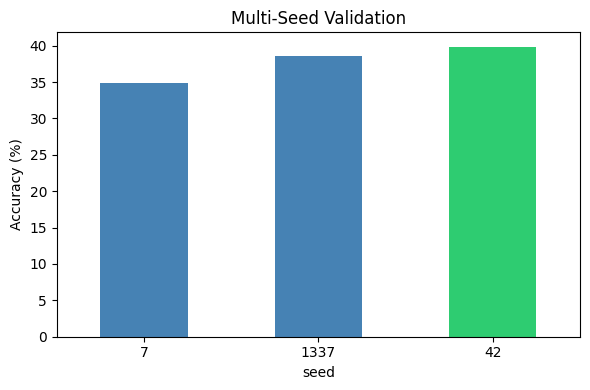

Mean: 37.78% ± 2.61%


In [ ]:
seed_df = plot_seed_runs("tripathysagar08/grpo-gsm8k")

In [ ]:
seed_df

,seed,accuracy
0,7,34.85
1,1337,38.64
2,42,39.85


## Run with epoch=1

In [ ]:
full_cfg = {
    'max_steps': 1000,
    'epochs': -1,
    'max_completion_length': 512,
    'beta': 0.02,
    'learning_rate': 5e-05,
    'num_generations': 16,
    'sft_frac': -1, #it uses the full train set
    'wandb_project': 'grpo-gsm8k-full',
}



exp = GRPOExperiment(full_cfg)
final_result = exp(push2hub=True)

README.md: 0.00B [00:00, ?B/s]

main/train-00000-of-00001.parquet:   0%|          | 0.00/2.31M [00:00<?, ?B/s]

main/test-00000-of-00001.parquet:   0%|          | 0.00/419k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/7473 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1319 [00:00<?, ? examples/s]

...

Passing `generation_config` together with generation-related arguments=({'disable_compile'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.


Step,Training Loss
1,0.054322
2,0.000000
3,0.000032
4,0.000033
5,0.000033
6,0.000040
7,-0.002149
8,0.000047
9,0.000059
10,-0.010070


Evaluating: 100%|██████████| 6/6 [00:42<00:00,  7.11s/it]


Final Accuracy: 299/660 = 45.30%


eval/accuracy,▁
profiling/Time taken: GRPOTrainer._calculate_rewards,█▁▁▁▁▁▁▁▁▁▁▁▁▁▂▁▁▁▁▇▁▂▁▁▁▁▁▂▁▁▁▁▁▁▁▂▁▁▁▁
profiling/Time taken: GRPOTrainer._get_per_token_logps_and_entropies,▁▁▁▁▁▁▁▁▁█▁▁▇▁▁▁▂▁▁▁▁▁█▁▁▁▁▁▇▁▁▁▁▂▂▁█▁▁▁
profiling/Time taken: GRPOTrainer._prepare_inputs,█▁▁▁▁█▁▁▁█▁▁▁▁▁▁▁██▁██▁▁▁██▁▁█▁▁█▁█▁▁▁▁█
profiling/Time taken: GRPOTrainer.compute_loss,▂▅▅▅▄█▆▁▃▅▇▃▄▆▆▁▁▁▅▂▆▃▁▆▁▁▃▆▆▇▃▅█▇██▄▇▅▄
profiling/Time taken: GRPOTrainer.reward_fn,▁▃▃▂▂▄▂▄▄▆█▂▁▄▆▁▆▂▆▁▅▃▃▃▁▂▂▁▁▁▁▁▆▃▃▂▁▃▂▁
profiling/Time taken: GRPOTrainer.transformers.generate,▄▁▄▂▃▂▂▆▅▁▃▂▅▃▃▅▂▃▃█▂▇▃▄▃▄▆▅▄▄▆▅▇▆▄▅▅▇▆▇
train/clip_ratio/high_max,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
train/clip_ratio/high_mean,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
train/clip_ratio/low_mean,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
+23,...


In [7]:
final_result

0.453030303030303